## Pricing American Options listed in SPDR S&P 500 ETF.

SPY options are American-style contracts written on the SPDR S&P 500 ETF, which closely tracks the S&P 500 index. Unlike European options, they incorporate realistic market features such as early exercise rights and discrete dividend payments, making their valuation considerably more challenging. As a result, SPY options provide an excellent benchmark for evaluating numerical methods for option pricing, under realistic market conditions. Furthermore, SPY options are among the most actively traded derivative instruments in the world, exhibiting high liquidity and tight bid-ask spreads, which enhances the reliability and consistency of the observed market data.

In the notebook, `SPX-HestonFourier-Calibration.ipynb`, the Heston stochastic volatility model is calibrated to European SPX options, whose underlying asset is the S&P 500 Index. In this notebook, the objective is to evaluate the predictive capability of the calibrated model when applied to a closely related, yet more complex market. To this end, the Heston parameters obtained from the SPX calibration are used here to price American SPY options with discrete dividends.

A custom finite-difference Heston pricing engine is developed based on the numerical methodology presented by Tinne Haentjens and Karel J. in 't Hout in *ADI Schemes for Pricing American Options under the Heston Model*. Throughout this project, this implementation is referred to as the **HH Heston solver** and is implemented in the `HestonFD` module.

After obtaining SPY option data and the corresponding dividend schedule from Yahoo Finance, the contracts are priced using both the **HH Heston solver** and **QuantLib**'s finite-difference Heston pricing engine. A large cross-section of American options is valued using both implementations and compared with observed market prices to assess the predictive capability of the Heston model calibrated to SPX options.

In addition to pricing vanilla American options, the **HH Heston solver** provides access to the full numerical solution of the pricing PDE, enabling the visualization and analysis of the option value surface, option Greeks, and the optimal early exercise boundary.

In [1]:
#============================================
# Import packages
#============================================
import sys
sys.path.append("../fetch_data")
sys.path.append("../option_pricing_engine")
sys.path.append("../utils")
import math
import numpy as np
import datetime
import matplotlib.cm as cm
np.set_printoptions(suppress=True,
formatter={'all': lambda x: '%5.3f' % x})
import pandas as pd
from scipy.optimize import brute, fmin, minimize
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'
import YfinanceFetchData
import CalibrationFilter
import HestonFD
import QLHestonFD
import ESFutures
import SOFR_zero_rate
import pickle
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
from IPython.display import Math, display

Applying following filters to obtain options data appropriate for the calibration of Heston model:
1. OTM/ATM puts and calls.
2. Expiry days ranging from 30 to 250.
3. Moneyness ranging from 0.80 to 1.25.
4. $\text{Bid}_\text{min} > 0$.
5. Bid-Ask Spread percent max: 15%.
6. Minimum option price: 0.50$

In [2]:
#=============================================================================================
# Fetching all the options data for the SPDR S&P 500 ETF, and the schedule for the dividends.
#=============================================================================================
now = datetime.datetime.now()
if (now.weekday() < 5) and (11 <= now.hour < 16):
    live=True
else:
    live=False
full_options_data, div_schedule = YfinanceFetchData.main(ticker='SPY', live=live)
options_data = CalibrationFilter.heston_filter(full_options_data, OTM=False)

  [dividends] SPY: avg $1.8813/payment every ~90 days → 9 projected payments through 2028-07-06

  Applying Heston filters …
    [10184]  start
    [5046]  DTE 30–300 days
    [3522]  moneyness 0.8–1.25
    [3519]  bid > 0.0
    [3394]  midPrice ≥ $0.5
    [3384]  spread ≤ 15% of mid
    [1485]  volume ≥ 10
    [1484]  IV 5%–150%

  Heston calibration set — 1484 contracts
     DTE   Puts  Calls  Total    Moneyness range
  --------------------------------------------------------
      31     83     55    138    0.832 – 1.058
      38     27     22     49    0.932 – 1.052
      45    123     88    211    0.805 – 1.131
      55     99     77    176    0.805 – 1.091
      73    153     92    245    0.801 – 1.111
      85     67     61    128    0.801 – 1.118
     101     31     29     60    0.805 – 1.138
     115     38     26     64    0.812 – 1.158
     136     31     18     49    0.812 – 1.191
     146     26     29     55    0.805 – 1.191
     164     33     32     65    0.812 – 1.218


In [3]:
full_options_data

,ticker,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,inTheMoney,dividendRate,dividendYield
0,SPY,751.2800,put,0,500.0000,0.0100,0.0000,0.0100,0.0050,24.0000,2.2500,False,7.5734,0.0101
1,SPY,751.2800,put,0,510.0000,0.0100,0.0000,0.0100,0.0050,NaN,2.1250,False,7.5734,0.0101
2,SPY,751.2800,put,0,530.0000,0.0100,0.0000,0.0100,0.0050,NaN,1.9375,False,7.5734,0.0101
3,SPY,751.2800,put,0,535.0000,0.0100,0.0000,0.0100,0.0050,1.0000,1.8750,False,7.5734,0.0101
4,SPY,751.2800,put,0,545.0000,0.0200,0.0000,0.0100,0.0050,NaN,1.8125,False,7.5734,0.0101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10179,SPY,751.2800,call,892,1450.0000,1.0000,1.0800,1.1400,1.1100,6.0000,0.1839,False,7.5734,0.0101
10180,SPY,751.2800,call,892,1460.0000,0.9900,1.0400,1.0600,1.0500,45.0000,0.1838,False,7.5734,0.0101
10181,SPY,751.2800,call,892,1470.0000,1.0400,1.0100,1.0700,1.0400,2.0000,0.1856,False,7.5734,0.0101
10182,SPY,751.2800,call,892,1480.0000,1.0000,0.9800,1.0400,1.0100,45.0000,0.1865,False,7.5734,0.0101


In [4]:
if live:
    today = datetime.date.today()
    with open("../options_data/saved_time.pkl", "wb") as file:
        pickle.dump(today, file)
    try:
        r = SOFR_zero_rate.get_sofr_rate([API_KEY_FOR_FRED])
    except NameError:
        r = np.load('../options_data/SOFR_rate.npy') # Uses saved SOFR rate if unable to get API key for FRED
    ES_futures = ESFutures.get_es_forward_curve()
else:
    with open("../options_data/saved_time.pkl", "rb") as file:
        today = pickle.load(file)
    r = np.load('../options_data/SOFR_rate.npy')
    ES_futures = pd.read_csv('../options_data/esfutures.csv')
pv_dividend = sum(amt * math.exp(-r * (d - today).days / 365.0) for d, amt in div_schedule)
print(f"The present value of all the dividends is equal to {round(pv_dividend, 3)}.")

The present value of all the dividends is equal to 16.224.


---

### Spot price estimation using the ES-mini S&P 500 Futures data 

The spot price reported alongside SPY option chain on Yahoo Finance is generally not synchronized with the quoted option prices. In many cases, it corresponds to the most recent closing price of the underlying ETF rather than the spot price prevailing when the options were quoted. For American options, put-call parity does not hold exactly because of the possibility of early exercise, and therefore cannot be reliably used to infer the underlying spot price.

To obtain a more consistent estimate of the spot price, the forward prices of E-mini S&P500 futures are used to infer the implied spot level of the S&P 500 index
$$S^{\text{SP500}}_0(T)=F_T e^{-r T}$$
where $F_T$ is the futures price with maturity $T$ and $r$ is the risk-free rate.

The implied spot price of SPY is then approximated using its close relationship with the S&P 500 index
$$S^{\text{SPY}}_0(T)\approx\frac{S^{\text{SP500}}_0(T)}{10}$$
where $D_i$ denotes the discrete dividend payments occurring before maturity.

While this approximation introduces a small degree of error due to tracking differences between SPY and its underlying index, it provides a practical and internally consistent estimate of the spot price for option pricing purposes. The spot price corresponding to the option is then obtained depending on its maturity by interpolating the term structure of $S_0$ obtained through the forward prices of E-mini S&P500 futures.

In [5]:
ES_futures = ES_futures.dropna(subset=['ForwardPrice'])
if live:
    ES_futures['time'] = ES_futures.apply(lambda row: (row['Expiry'].date()-today).days/365., axis=1)
else:
    ES_futures['time'] = ES_futures.apply(lambda row: (datetime.datetime.strptime(row['Expiry'], '%Y-%m-%d').date()-today).days/365., axis=1)
ES_futures['spot_estimate'] = ES_futures.apply(lambda row: math.exp(-r*row['time'])*row['ForwardPrice'], axis=1)

In [6]:
ES_futures

,Ticker,Expiry,ForwardPrice,time,spot_estimate
0,ESU26.CME,2026-09-18,7575.7500,0.2000,7520.7988
1,ESZ26.CME,2026-12-18,7647.7500,0.4493,7523.6878
2,ESH27.CME,2027-03-18,7734.7500,0.6959,7541.2862


In [7]:
np.array(ES_futures['spot_estimate'])

array([7520.799, 7523.688, 7541.286])

In [8]:
#============================================
# Adding the implied spot price for options
# depending on their maturity
#============================================
S0_curve = PchipInterpolator(np.array(ES_futures['time']), np.array(ES_futures['spot_estimate']))
options_data['spot_imp'] = options_data.apply(lambda row: S0_curve(row['dte']/365.)/10., axis=1)

In [9]:
options_data

,ticker,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spread_pct,inTheMoney,dividendRate,dividendYield,spot_imp
0,SPY,751.2800,call,31,625.0000,109.1500,128.2000,131.0000,129.6000,10.0000,0.4868,0.8319,0.0216,True,7.5734,0.0101,752.1663
1,SPY,751.2800,put,31,635.0000,0.5100,0.4900,0.5100,0.5000,264.0000,0.2855,0.8452,0.0400,False,7.5734,0.0101,752.1663
2,SPY,751.2800,put,31,640.0000,0.5400,0.5300,0.5500,0.5400,10.0000,0.2775,0.8519,0.0370,False,7.5734,0.0101,752.1663
3,SPY,751.2800,put,31,645.0000,0.5900,0.5800,0.5900,0.5850,12.0000,0.2691,0.8585,0.0171,False,7.5734,0.0101,752.1663
4,SPY,751.2800,call,31,650.0000,100.7000,103.5100,106.3100,104.9100,26.0000,0.4149,0.8652,0.0267,True,7.5734,0.0101,752.1663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,SPY,751.2800,call,267,880.0000,5.8100,5.9300,5.9900,5.9600,323.0000,0.1536,1.1713,0.0101,False,7.5734,0.0101,754.4912
1480,SPY,751.2800,call,267,890.0000,4.1800,4.7600,4.8100,4.7850,10.0000,0.1518,1.1846,0.0104,False,7.5734,0.0101,754.4912
1481,SPY,751.2800,call,267,895.0000,3.8000,4.2500,4.3000,4.2750,30.0000,0.1509,1.1913,0.0117,False,7.5734,0.0101,754.4912
1482,SPY,751.2800,call,267,905.0000,3.3600,3.3900,3.4300,3.4100,77.0000,0.1494,1.2046,0.0117,False,7.5734,0.0101,754.4912


In [10]:
#============================================
# Current spot price of the SPDR S&P500 ETF
#============================================
S0 = ES_futures['spot_estimate'].mean()/10.

In [11]:
options_data = options_data.drop(columns=['ticker', 'spot', 'dividendRate', 'dividendYield', 'spread_pct', 'inTheMoney'])
options_data

,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spot_imp
0,call,31,625.0000,109.1500,128.2000,131.0000,129.6000,10.0000,0.4868,0.8319,752.1663
1,put,31,635.0000,0.5100,0.4900,0.5100,0.5000,264.0000,0.2855,0.8452,752.1663
2,put,31,640.0000,0.5400,0.5300,0.5500,0.5400,10.0000,0.2775,0.8519,752.1663
3,put,31,645.0000,0.5900,0.5800,0.5900,0.5850,12.0000,0.2691,0.8585,752.1663
4,call,31,650.0000,100.7000,103.5100,106.3100,104.9100,26.0000,0.4149,0.8652,752.1663
...,...,...,...,...,...,...,...,...,...,...,...
1479,call,267,880.0000,5.8100,5.9300,5.9900,5.9600,323.0000,0.1536,1.1713,754.4912
1480,call,267,890.0000,4.1800,4.7600,4.8100,4.7850,10.0000,0.1518,1.1846,754.4912
1481,call,267,895.0000,3.8000,4.2500,4.3000,4.2750,30.0000,0.1509,1.1913,754.4912
1482,call,267,905.0000,3.3600,3.3900,3.4300,3.4100,77.0000,0.1494,1.2046,754.4912


In [12]:
options_data = options_data[options_data['dte']>0.]

---

## ADI Hundsdorfer Scheme for Pricing American Options with Discrete Dividends under the Heston Stochastic Volatility Framework

### Introduction

In this project, the option pricing problem is solved numerically using a finite-difference discretization of the two-dimensional Heston partial differential complementarity problem (PDCP). To efficiently handle the mixed derivative term and the high dimensionality of the problem, an Alternating Direction Implicit (ADI) scheme with Ikonen-Toivanen (IT) splitting method is employed, specifically the Hundsdorfer-Verwer (HV) scheme. This implementation is mainly based on the method outlined in the paper "ADI schemes for pricing American options under the Heston model" by T. Haentjens and K. J. in't Hout.

The ADI-Hundsdorfer scheme is attractive because it:

* is unconditionally stable for practical grid sizes,
* efficiently handles the mixed derivative term arising from correlation,
* allows large time steps compared to explicit methods,
* is computationally efficient for two-dimensional PDEs,
* can be naturally combined with American early exercise constraints.

Compared with tree methods or Monte Carlo Longstaff-Schwartz approaches, the ADI finite-difference framework generally produces more stable and accurate early exercise boundaries.


The value of the option, $V(S,v,t)$ satisfies the Heston PDE:

$$\frac{\partial V}{\partial t}+\frac{1}{2}vS^2\frac{\partial^2V}{\partial S^2}+\rho\sigma vS\frac{\partial^2V}{\partial S\partial v}+\frac{1}{2}\sigma^2v\frac{\partial^2V}{\partial v^2}+(r-q)S\frac{\partial V}{\partial S}+\kappa(\theta-v)\frac{\partial V}{\partial v}-rV=0$$

The mixed derivative term
$\rho\sigma vS\frac{\partial^2V}{\partial S\partial v}$
creates numerical difficulties and motivates the use of ADI splitting methods.


For an American option, the PDE becomes a partial differential complementarity problem (PDCP):
For an American put:
$$V(S,v,t)\geq \max(K-S,0)$$
together with
$\frac{\partial V}{\partial t}+\mathcal{L}V\leq 0$
and the complementarity condition
$$\left(V-\Phi\right)\left(\frac{\partial V}{\partial t}+\mathcal{L}V\right)=0$$
where:

* $\mathcal{L}$ is the Heston differential operator,
* $\Phi$ is the payoff function.

The condition implies that either:
1. the PDE holds in the continuation region, or
2. the option value equals intrinsic value in the exercise region.

In practice Heston PDEs are numerically solved backwards in time, i. e. $V = V(S, v, \tau)$
where $\tau \equiv T - t$ is the time to maturity. 
### Initial  conditions
$$
V(S, v, \tau = 0) = 
\begin{cases} 
\text{max}(K-S, 0) & \text{for vanilla Americana puts} \\
\text{max}(S-K, 0) & \text{for vanilla American calls}
\end{cases}
$$
### Boundary conditions
$$V(S=0, v, \tau) =
\begin{cases}
K e^{-r\tau} & \text{for vanilla American puts}\\
0 & \text{for vanilla American calls}
\end{cases}
$$  
$$V(S\rightarrow\infty, v, \tau) =
\begin{cases}
0 & \text{for vanilla American puts}\\
S - Ke^{-r\tau} & \text{for vanilla American calls}
\end{cases}
$$ 
$$\frac{\partial V}{\partial v}\Bigg|_{v\rightarrow \infty} = 0$$

---

### Numerical Implementation Method

The PDE is discretized on a two-dimensional grid:

* asset price grid: {$S_i>0$: $1\leq i\leq m_1$} where $S_{m_1} = S_\text{max}$. 
* variance grid: {$v_j$: $0\leq j \leq m_2$} where $v_0=0$.

Finite differences are used:

* central differences for diffusion terms,
* forward and backward differences for convection terms,
* 9-point centralized stencil through successive central differences for the mixed derivative term.

The semi-discrete system becomes

$\frac{dU}{dt} = AU + g$

where:

* $U$ is the vector of option values on the grid of dimension $M\equiv m_1(m_2+1)$,
* $A$ is the discretized Heston operator matrix of size $M\times M$.
* $g$ incorporates the boundary conditions.

The matrix is decomposed into directional operators:

$$A=A_0+A_1+A_2$$

where:

* $A_0$: mixed derivative term,
* $A_1$: $S$-direction terms,
* $A_2$: $v$-direction terms.

and the $-r I$ term is split equally between the matrices, $A_1$ and $A_2$. This decomposition is central to the ADI approach.

The Hundsdorfer-Verwer scheme is a second-order ADI time-stepping method designed for multidimensional PDEs. Given timestep ($\Delta t$), the scheme advances the solution from $U_{n-1}$ to $U_{n}$ through a sequence of implicit directional solves.

The method consists of:

* Predictor Step: $$Y_0 = \hat{U}_{n-1} + \Delta t( A \hat{U}_{n-1}+ g +\bar{\lambda}_{n})$$

* Directional Implicit Corrections - 1
$$(I-\theta\Delta t A_1)Y_1=Y_0-\theta\Delta t A_1\hat{U}_{n-1}$$
$$(I-\theta\Delta t A_2)Y_2=Y_1-\theta\Delta t A_2\hat{U}_{n-1}$$

* Second Correction Stage $$\widetilde{Y}_0=Y_0+\frac{1}{2}\Delta t A(Y_2-\hat{U}_{n-1})$$

* Directional Implicit Corrections - 2
$$(I-\theta\Delta t A_1)\widetilde{Y}_1=\widetilde{Y}_0-\theta\Delta t A_1Y_2$$
$$(I-\theta\Delta t A_2)\widetilde{Y}_2=\widetilde{Y}_1-\theta\Delta t A_2Y_2$$

* Prediction for the current time instant
$$\bar{U}_n = \widetilde{Y}_2$$

* Projection step for American exercise
$$\hat{U}_n = \text{max}(\bar{U}_n - \Delta t \bar{\lambda}_n, U_0)$$
$$\hat{\lambda}_{n} = \text{max}(0, \bar{\lambda}_n + (U_0-\bar{U}_n)/\Delta t)$$

Here $\hat{\lambda}_n = 0$ characterizes the continuation region and $\hat{\lambda}>0$ is the exercise region.
The optimal exercise boundary is obtained by determining the boundary between the two regions at each time step.

The parameter, $\theta$ is commonly chosen as:
$$\theta=\frac{1}{2}+\frac{\sqrt{3}}{6}$$
which provides good stability properties.

The key advantage is that each implicit solve only involves one spatial direction at a time, leading to tridiagonal linear systems that can be solved efficiently. The mixed derivative term is handled explicitly in the HV scheme through operator splitting. This avoids solving a fully coupled two-dimensional linear system while still maintaining second-order temporal accuracy. The mixed derivative term is especially important in the Heston model because:

* it captures correlation between stock and variance,
* it strongly affects skew and smile behaviour,
* neglecting it can produce large pricing errors.

The HV scheme is known to remain stable even for large correlation values ($|\rho|\approx 1$).

Since the terminal payoff doesn't have a finite second partial derivative with respect to the asset price,
we use implicit backward Euler method for four half-time steps in the first two time steps. This is called 
Rannacher smoothing.
$$\left(I - \frac{\Delta t}{2}A_1\right)U_{n}^* = \hat{U}_{n-1} $$
$$\left(I - \frac{\Delta t}{2}A_2\right)\bar{U}_n = U_{n}^* $$
$$\hat{U}_n = \bar{U}_{n}+\frac{\Delta t}{2} \left(A_0 \hat{U}_{n-1}-r\hat{U}_{n-1} + g\right)$$

---

### Treatment of Dividends in the American Option Pricing Framework

The SPDR S&P500 ETF (SPY) pays dividends discretely at specific ex-dividend dates throughout the year. Since dividend payments directly affect the stock price dynamics, they must be incorporated carefully into the option pricing framework. In particular, dividends are highly relevant when pricing American options because they influence the optimal early exercise boundary.

In this project, two different approaches are considered for incorporating dividends into the pricing model:

1. Approximating dividends as continuous payments,
2. Modelling dividends explicitly as discrete cash payments.

The first method is computationally simpler and is commonly used in standard Black-Scholes implementations, whereas the second method provides a more realistic representation of the actual market behaviour of SPY.

#### 1. Continuous Dividend Approximation

A common simplification in option pricing is to approximate discrete dividend payments using a continuous dividend adjustment. Instead of modelling the actual jumps in the stock price at dividend dates, the present value of all expected future dividend payments is subtracted from the spot price.

If the underlying pays dividends, $D_i$ at times, $t_i$ before maturity, $T$, the adjusted spot price, $S_\text{adj}$, is written as

$$S_\text{adj} = S_0 -\sum_{t_i\leq T} D_i e^{-r t_i}$$


The idea behind this adjustment is that the current stock price already reflects the market expectation of future dividend payouts. By subtracting the discounted dividends, the pricing model effectively works with a synthetic non-dividend-paying asset.

After computing $S_\text{adj}$, the option pricing PDE is solved using the ADI HV finite-difference method. In this approach, the adjusted spot replaces the original spot price throughout the numerical pricing procedure.

The main drawback of this method is that it ignores the discontinuous jump in the stock price occurring on the ex-dividend date, which siginificantly affects the early exercise behaviour of American options, especially for short-dated contracts and deep in-the-money options. Since the continuous approximation smooths out these jumps, it fails to capture the true exercise premium associated with discrete dividends. As a result:

* non-ITM puts are often underpriced,
* non-ITM calls are often overpriced,
* the early exercise boundary becomes less accurate,
* short maturity options can exhibit noticeable pricing errors.

Therefore, although the continuous dividend approximation is computationally efficient, it is not fully realistic for pricing American options on dividend-paying ETFs such as SPY.

#### 2. Explicit Treatment of Discrete Dividends

To model the dividend payments more realistically, the dividends are treated explicitly as discrete cash payments occurring at known ex-dividend dates.
Under this framework, the stock price process experiences downward jumps whenever a dividend is paid. Consequently, the option value must satisfy a jump condition across the dividend date.

$$S_{t_i^+}= S_{t_i^-}-D_i \,\, \Rightarrow \,\, S_{\tau_{i}^-}= S_{\tau_{i}^+}-D_i$$

To ensure no-arbitrage consistency, the option value must satisfy the jump condition
$$V(S,v,\tau_{i}^+)=V(S-D_i,v,\tau_{i}^-)$$
where:
* $V(S,v,\tau_{i}^-)$ is the option value immediately before the dividend payment,
* $V(S-D_i,v,\tau_{i}^{+})$ is the option value immediately after the dividend payment evaluated at the shifted stock price.
This condition states that the option value before the dividend must equal the option value after the stock price has jumped downward by the dividend amount.

Whenever the numerical time-stepping procedure reaches a dividend date:
1. the solution is first advanced to $\tau_{i}^-$,
2. the stock grid is shifted by the dividend amount $D_i$,
3. interpolation is performed to evaluate
   $V(S, v, \tau_{i}^+) = \text{interpolate}(V(S-D_i,v,\tau_{i}^-))$,
4. apply early exercise projection,
5. the backward time-stepping then continues.

Note:
* Interpolation is necessary because the shifted grid points generally do not align exactly with the original finite-difference grid. Typically, linear interpolation or cubic spline interpolation is used.


---

## Full Numerical Workflow

The complete pricing algorithm proceeds as follows:

1. Construct the $S$-grid and $v$-grid.
2. Initialize terminal payoff at maturity.
3. Discretize the Heston operator matrices.
4. Incorporate boundary conditions.
5. First two backward steps to implement
   Rannacher smoothing of the fair value of the option.
6. Subsequent steps using the HV ADI scheme.
7. At each timestep:
   * update boundary conditions,
   * apply implicit directional solves,
   * enforce early exercise projection.
8. At dividend dates:
   * apply the jump condition,
   * interpolate onto shifted grids,
   * apply early exercise projection.
9. Continue until reaching $t=0$.
10. Interpolate the option value at the initial state ($S_0$, $v_0$).

In [13]:
#===============================================================================================
# Attaching columns for the ex-dividend dates (which are before the expiry date of the option) 
# and the corresponding divident amounts. From this we obtain the adjusted spot price 
# relevant for the option.
#===============================================================================================
def _attach_dividend_cols(df: pd.DataFrame, div_schedule: list) -> pd.DataFrame:
    """
    Add three columns to options_data dataframe for each option row:

        divs_before_expiry – semicolon-separated "YYYY-MM-DD:$amount" pairs
                             for every ex-div date that falls between today
                             and the option's expiry date (inclusive).
                             Empty string if none.

        pv_dividends       – present value of those dividends discounted
                             continuously at risk-free rate r:
                             PV = Σ D_i × exp(−r × t_i)
                             where t_i = days_to_ex_div / 365

        spot_adj           – forward-adjusted spot used in Heston pricing:
                             spot_adj = spot − pv_dividends                        

    Parameters
    ----------
    df           : options DataFrame (must have columns: spot, dte)
    div_schedule : list of (datetime.date, float)
    r            : continuously compounded risk-free rate (default 5%)
    """
    import math
    today = datetime.date.today()
    divs_dates_list = []
    divs_amounts_list = []
    divs_before_list   = []
    pv_list            = []
    spot_adj_list      = []
    for _, row in df.iterrows():
        expiry = today + datetime.timedelta(days=int(row["dte"]))
        relevant = [(d, amt) for d, amt in div_schedule
                    if today < d <= expiry]
        relevant_divs = [((d - today).days, amt) for d, amt in div_schedule
                    if today < d <= expiry]

        if relevant:
            pv  = sum(amt * math.exp(-r * (d - today).days / 365.0) for d, amt in relevant)
            tag = ";".join(f"{d}:{amt:.4f}" for d, amt in relevant)
        else:
            pv  = 0.0
            tag = ""
        if relevant_divs:
            divs_dates, divs_amounts = map(list, zip(*relevant_divs))
            divs_dates_list.append(divs_dates)
            divs_amounts_list.append(divs_amounts)
            divs_before_list.append(tag)
            spot_adj_list.append(row['spot_imp']-pv)
        else:
            divs_dates_list.append([])
            divs_amounts_list.append([])
            divs_before_list.append([])
            spot_adj_list.append(row['spot_imp'])

    df = df.copy()
    df["dividend_dates"] = divs_dates_list
    df["dividend_amounts"] = divs_amounts_list
    df["divs_before_expiry"] = divs_before_list
    df["spot_adj"] = spot_adj_list
    return df
options_data = _attach_dividend_cols(options_data, div_schedule)

In [14]:
options_data

,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spot_imp,dividend_dates,dividend_amounts,divs_before_expiry,spot_adj
0,call,31,625.0000,109.1500,128.2000,131.0000,129.6000,10.0000,0.4868,0.8319,752.1663,[],[],[],752.1663
1,put,31,635.0000,0.5100,0.4900,0.5100,0.5000,264.0000,0.2855,0.8452,752.1663,[],[],[],752.1663
2,put,31,640.0000,0.5400,0.5300,0.5500,0.5400,10.0000,0.2775,0.8519,752.1663,[],[],[],752.1663
3,put,31,645.0000,0.5900,0.5800,0.5900,0.5850,12.0000,0.2691,0.8585,752.1663,[],[],[],752.1663
4,call,31,650.0000,100.7000,103.5100,106.3100,104.9100,26.0000,0.4149,0.8652,752.1663,[],[],[],752.1663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,call,267,880.0000,5.8100,5.9300,5.9900,5.9600,323.0000,0.1536,1.1713,754.4912,"[71, 161, 251]","[1.8813, 1.8813, 1.8813]",2026-09-16:1.8813;2026-12-15:1.8813;2027-03-15...,748.9371
1480,call,267,890.0000,4.1800,4.7600,4.8100,4.7850,10.0000,0.1518,1.1846,754.4912,"[71, 161, 251]","[1.8813, 1.8813, 1.8813]",2026-09-16:1.8813;2026-12-15:1.8813;2027-03-15...,748.9371
1481,call,267,895.0000,3.8000,4.2500,4.3000,4.2750,30.0000,0.1509,1.1913,754.4912,"[71, 161, 251]","[1.8813, 1.8813, 1.8813]",2026-09-16:1.8813;2026-12-15:1.8813;2027-03-15...,748.9371
1482,call,267,905.0000,3.3600,3.3900,3.4300,3.4100,77.0000,0.1494,1.2046,754.4912,"[71, 161, 251]","[1.8813, 1.8813, 1.8813]",2026-09-16:1.8813;2026-12-15:1.8813;2027-03-15...,748.9371


In [15]:
#-------------------------------------
# Spot price term structure
#-------------------------------------
options_data.groupby('dte')['spot_imp'].first()

dte
31    752.1663
38    752.1390
45    752.1171
55    752.0949
73    752.0799
85    752.0861
101   752.1125
115   752.1506
136   752.2302
146   752.2760
164   752.3688
177   752.4759
192   752.6803
255   754.1563
267   754.4912
Name: spot_imp, dtype: float64

In [16]:
#========================================================================================
# Using the Heston parameters obtained upon calibration to the European SPX options
#========================================================================================
heston_calibrated_params = np.load('../options_data/Heston_parameters_SPX.npy')
kappa_v, theta_v, sigma_v, rho, v0 = heston_calibrated_params

In [17]:
heston_calibrated_params

array([5.541, 0.047, 1.482, -0.675, 0.020])

In [18]:
unique_options_expiry = options_data['dte'].unique()
unique_options_expiry

array([31.000, 38.000, 45.000, 55.000, 73.000, 85.000, 101.000, 115.000,
       136.000, 146.000, 164.000, 177.000, 192.000, 255.000, 267.000])

---
### Pricing Engines

The SPY options are priced using three different approaches:

1. The QuantLib Heston finite-difference pricing engine with the **escrowed dividend approximation**.
2. The QuantLib Heston finite-difference pricing engine with **dividend jump interpolation**.
3. HH Heston finite-difference pricing engine with **dividend jump interpolation**.

The first two approaches are implemented using the `QLHestonFD` module, while the custom HH Heston solver is implemented using the `HestonFD` module.

In [19]:
#=======================================================================
# Calculating option prices at different strikes for a given maturity
#=======================================================================

today = datetime.date.today()
DTE = unique_options_expiry[9]
options_exp_val = options_data[options_data['dte'].isin([DTE])]
Sp = options_exp_val['spot_imp'].unique()[0]
Sadj = options_exp_val['spot_adj'].unique()[0]

relevant_divs = [((d - today).days, amt) for d, amt in div_schedule if today < d <= today + datetime.timedelta(days=int(DTE))]
if len(relevant_divs)>0:
    dividend_dates, dividend_amounts = map(list, zip(*relevant_divs))
else:
    dividend_dates = []
    dividend_amounts = []
    

heston_fitted_data = pd.DataFrame()
heston_fitted_data['strike'] = np.linspace(options_exp_val['strike'].min(), options_exp_val['strike'].max(), 100)

#=======================================================================
# Pricing options using the QuantLib finite-difference pricing engine
# by using the escrowed dividend approximation.
#=======================================================================

heston_fitted_data['QLFD_cont_call_model_value'] = heston_fitted_data.apply(lambda row: QLHestonFD.price_heston_american(Sadj, row['strike'], r, 0., DTE, v0, kappa_v, theta_v, sigma_v, rho, 'call', False)['price'], axis=1)
heston_fitted_data['QLFD_cont_put_model_value'] = heston_fitted_data.apply(lambda row: QLHestonFD.price_heston_american(Sadj, row['strike'], r, 0., DTE, v0, kappa_v, theta_v, sigma_v, rho, 'put', False)['price'], axis=1)

#=======================================================================
# Pricing options using the QuantLib finite-difference pricing engine
# b using ydividend jump interpolation on the ex-dividend date.
#=======================================================================

heston_fitted_data['QLFD_disc_call_model_value'] = heston_fitted_data.apply(lambda row: QLHestonFD.price_heston_american(Sp, row['strike'], r, 0., DTE, v0, kappa_v, theta_v, sigma_v, rho, 'call', dividend_dates, dividend_amounts)['price'], axis=1)
heston_fitted_data['QLFD_disc_put_model_value'] = heston_fitted_data.apply(lambda row: QLHestonFD.price_heston_american(Sp, row['strike'], r, 0., DTE, v0, kappa_v, theta_v, sigma_v, rho, 'put', dividend_dates, dividend_amounts)['price'], axis=1)

#=======================================================================
# Pricing options using the ADI-IT finite-difference method, by using
# dividend jump interpolation on the ex-dividend date.
#=======================================================================

heston_fitted_data['HHFD_call_model_value'] = heston_fitted_data.apply(lambda row: HestonFD.HestonFD_ADI_HV(Sp, r, row['strike'], DTE/365., 'call', heston_calibrated_params,\
                                           dividend_dates=np.array(dividend_dates)/365., dividend_amounts=np.array(dividend_amounts)).price_heston(m1=150, m2=75, M=112)[0], axis=1)
heston_fitted_data['HHFD_put_model_value'] = heston_fitted_data.apply(lambda row: HestonFD.HestonFD_ADI_HV(Sp, r, row['strike'], DTE/365., 'put', heston_calibrated_params,\
                                           dividend_dates=np.array(dividend_dates)/365., dividend_amounts=np.array(dividend_amounts)).price_heston(m1=150, m2=75, M=112)[0], axis=1)

In [20]:
heston_fitted_data

,strike,QLFD_cont_call_model_value,QLFD_cont_put_model_value,QLFD_disc_call_model_value,QLFD_disc_put_model_value,HHFD_call_model_value,HHFD_put_model_value
0,605.0000,158.5703,4.4427,158.5824,4.4531,158.3039,4.4533
1,607.9293,155.8387,4.6008,155.8511,4.6115,155.5769,4.6123
2,610.8586,153.1122,4.7643,153.1249,4.7752,152.8551,4.7764
3,613.7879,150.3912,4.9334,150.4042,4.9446,150.1388,4.9460
4,616.7172,147.6759,5.1083,147.6892,5.1197,147.4281,5.1218
...,...,...,...,...,...,...,...
95,883.2828,0.9228,132.8749,0.9274,131.0068,0.9638,131.0068
96,886.2121,0.8534,135.8042,0.8576,133.9361,0.8908,133.9361
97,889.1414,0.7898,138.7335,0.7937,136.8654,0.8241,136.8654
98,892.0707,0.7314,141.6627,0.7351,139.7947,0.7628,139.7947


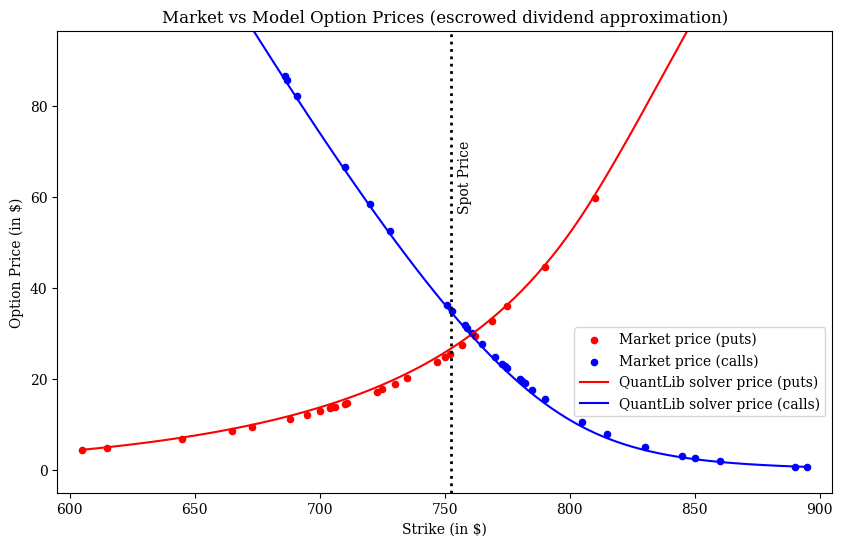

In [21]:
#=======================================================================
# Plotting option prices at different strikes for a given maturity
#=======================================================================

#--------------------------------------------------------------
# Scatter plot of the actual option prices listed for the ETF
#--------------------------------------------------------------

ax11 = options_exp_val[options_exp_val['type']=='put'].plot.scatter(x='strike', y='midPrice', c='red', label="Market price (puts)", figsize=(10,6))
options_exp_val[options_exp_val['type']=='call'].plot.scatter(x='strike', y='midPrice', c='blue', label="Market price (calls)", ax=ax11)
ax11.set_title("Market vs Model Option Prices (escrowed dividend approximation)");
ax11.set_xlim([options_exp_val['strike'].min()-10., options_exp_val['strike'].max()+10.])
ax11.set_ylim([-5., options_exp_val['midPrice'].max()+10.])
ax11.axvline(x=Sp, color='black', linestyle=':', linewidth=2)
ax11.text(Sp+3, ax11.get_ylim()[1]*0.75, 'Spot Price', rotation=90, verticalalignment='top')

#------------------------------------------------------------------------------------
# Plotting option prices predicted by the QuantLib finite-difference pricing engine
#------------------------------------------------------------------------------------
heston_fitted_data.plot(x='strike', y='QLFD_cont_put_model_value', kind='line', color='red', ax=ax11, label='QuantLib solver price (puts)');
heston_fitted_data.plot(x='strike', y='QLFD_cont_call_model_value', kind='line', color='blue', ax=ax11, label='QuantLib solver price (calls)');
ax11.set_ylabel('Option Price (in \$)')
ax11.set_xlabel('Strike (in \$)')
ax11.legend(loc='lower right', bbox_to_anchor=(1, 0.15), fontsize=10);

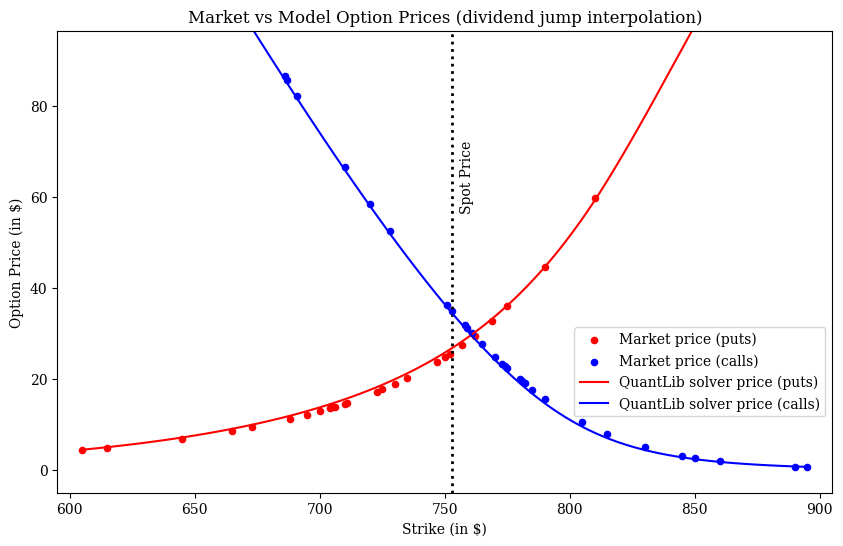

In [22]:
#=======================================================================
# Plotting option prices at different strikes for a given maturity
#=======================================================================

#--------------------------------------------------------------
# Scatter plot of the actual option prices listed for the ETF
#--------------------------------------------------------------
ax12 = options_exp_val[options_exp_val['type']=='put'].plot.scatter(x='strike', y='midPrice', c='red', label="Market price (puts)", figsize=(10,6))
options_exp_val[options_exp_val['type']=='call'].plot.scatter(x='strike', y='midPrice', c='blue', label="Market price (calls)", ax=ax12)
ax12.set_title("Market vs Model Option Prices (dividend jump interpolation)")
ax12.set_xlim([options_exp_val['strike'].min()-10., options_exp_val['strike'].max()+10.])
ax12.set_ylim([-5., options_exp_val['midPrice'].max()+10.])
ax12.axvline(x=S0, color='black', linestyle=':', linewidth=2)
ax12.text(S0+3, ax12.get_ylim()[1]*0.75, 'Spot Price', rotation=90, verticalalignment='top')
#------------------------------------------------------------------------------------
# Plotting option prices predicted by the QuantLib finite-difference pricing engine
#====================================================================================
heston_fitted_data.plot(x='strike', y='QLFD_disc_put_model_value', kind='line', color='red', ax=ax12, label='QuantLib solver price (puts)');
heston_fitted_data.plot(x='strike', y='QLFD_disc_call_model_value', kind='line', color='blue', ax=ax12, label='QuantLib solver price (calls)');
ax12.legend(loc='lower right', bbox_to_anchor=(1, 0.15), fontsize=10)
ax12.set_ylabel('Option Price (in \$)')
ax12.set_xlabel('Strike (in \$)')
ax12.get_figure().savefig('../figures/american_qlpricing_plot.png', dpi=300, bbox_inches='tight')

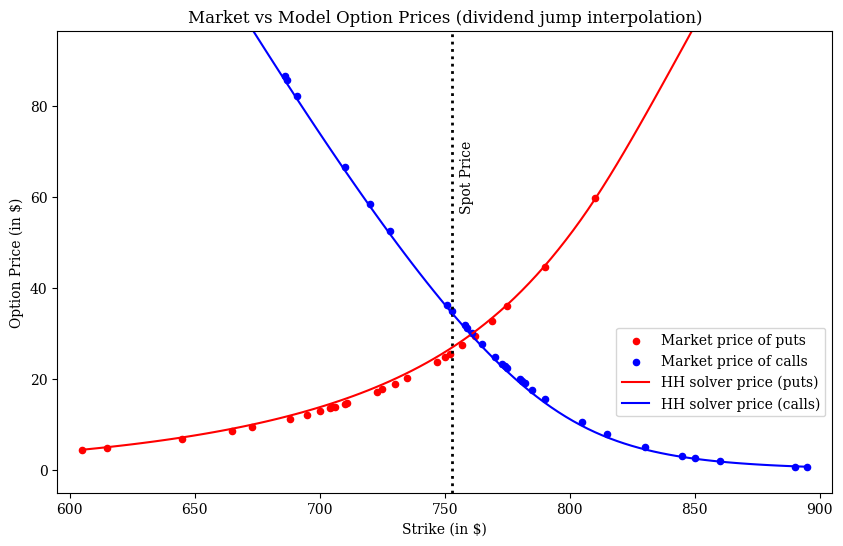

In [23]:
#=======================================================================
# Plotting option prices at different strikes for a given maturity
#=======================================================================

#--------------------------------------------------------------
# Scatter plot of the actual option prices listed for the ETF
#--------------------------------------------------------------
ax12 = options_exp_val[options_exp_val['type']=='put'].plot.scatter(x='strike', y='midPrice', c='red', label="Market price of puts", figsize=(10,6))
options_exp_val[options_exp_val['type']=='call'].plot.scatter(x='strike', y='midPrice', c='blue', label="Market price of calls", ax=ax12)
ax12.set_title("Market vs Model Option Prices (dividend jump interpolation)")
ax12.set_xlim([options_exp_val['strike'].min()-10., options_exp_val['strike'].max()+10.])
ax12.set_ylim([-5., options_exp_val['midPrice'].max()+10.])
ax12.axvline(x=S0, color='black', linestyle=':', linewidth=2)
ax12.text(S0+3, ax12.get_ylim()[1]*0.75, 'Spot Price', rotation=90, verticalalignment='top')
#------------------------------------------------------------------------------------
# Plotting option prices predicted by the HH ADI finite-difference pricing engine
#====================================================================================
heston_fitted_data.plot(x='strike', y='HHFD_put_model_value', kind='line', color='red', ax=ax12, label='HH solver price (puts)');
heston_fitted_data.plot(x='strike', y='HHFD_call_model_value', kind='line', color='blue', ax=ax12, label='HH solver price (calls)');
ax12.legend(loc='lower right', bbox_to_anchor=(1, 0.15), fontsize=10)
ax12.set_ylabel('Option Price (in \$)')
ax12.set_xlabel('Strike (in \$)')
ax12.get_figure().savefig('../figures/american_hhpricing_plot.png', dpi=300, bbox_inches='tight')

The results indicate that the escrowed dividend approximation tends to overprice put options and underprice call options which are expiring in a few days after an ex-dividend date. By replacing the actual stock price with an adjusted spot price,

$$
S_{\text{adj}} = S_0 - \sum_{t_i\leq T} D_i e^{-r t_i},
$$

the model effectively assumes that future dividend payments have already been incorporated into the underlying asset price. While computationally convenient, this approach ignores the discrete downward jumps in the stock price that occur on ex-dividend dates.

Because the adjusted spot price is lower than the actual market price, the model artificially shifts the underlying closer to the put's payoff region and further away from the call's payoff region. As a result, put options appear more valuable, while call options appear less valuable than they would under a framework that explicitly accounts for discrete dividends.

More importantly, the escrowed dividend approach fails to capture the timing and magnitude of dividend-induced stock price jumps, which can significantly influence option values and early exercise decisions. This effect is particularly relevant for American-style options, where dividend events contribute to the exercise premium. By smoothing dividends into a single adjustment at time zero, the model neglects these dynamics and can introduce systematic pricing biases.

In contrast, explicitly modelling dividends through the jump condition preserves the correct stock price dynamics and generally produces option valuations that are more consistent with observed market prices.

---

In [24]:
options_exp_val

,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spot_imp,dividend_dates,dividend_amounts,divs_before_expiry,spot_adj
1120,put,146,605.0000,4.9700,4.4200,4.4600,4.4400,325.0000,0.2535,0.8053,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
1121,put,146,615.0000,5.4800,4.9200,4.9600,4.9400,32.0000,0.2454,0.8186,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
1122,put,146,645.0000,7.7100,6.8300,6.8700,6.8500,15.0000,0.2212,0.8585,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
1123,put,146,665.0000,10.2000,8.5500,8.6100,8.5800,10.0000,0.2051,0.8852,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
1124,put,146,673.0000,11.9400,9.3800,9.4300,9.4050,121.0000,0.1985,0.8958,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1170,call,146,845.0000,2.7200,3.0700,3.1100,3.0900,30.0000,0.1405,1.1247,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
1171,call,146,850.0000,2.4500,2.5900,2.6300,2.6100,751.0000,0.1396,1.1314,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
1172,call,146,860.0000,1.8700,1.8600,1.8800,1.8700,31.0000,0.1382,1.1447,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080
1173,call,146,890.0000,0.6800,0.7000,0.7300,0.7150,208.0000,0.1382,1.1846,752.2760,[71],[1.8813],2026-09-16:1.8813,750.4080


In [25]:
#====================================================================
# Comparison Between Model-Predicted and Market Option Price
# for one of the options
#====================================================================
#------------------------------------------------
# Choosing a near-the-money option
#------------------------------------------------
options_exp_val_puts = options_exp_val[options_exp_val['type']=='put'].reset_index(drop=True)
options_exp_val_calls = options_exp_val[options_exp_val['type']=='call'].reset_index(drop=True)
Sp = options_exp_val['spot_imp'].unique()[0]
target_strike_put = 0.96 * Sp
target_strike_call = 1.04 * Sp
put_opt = options_exp_val_puts.iloc[(options_exp_val_puts['strike'] - target_strike_put).abs().idxmin()]
call_opt = options_exp_val_calls.iloc[(options_exp_val_calls['strike'] - target_strike_call).abs().idxmin()]
DTE_e = put_opt['dte']
K_pe = put_opt['strike']
K_ce = call_opt['strike']
div_dates_e = put_opt['dividend_dates']
div_amounts_e = put_opt['dividend_amounts']
Put = HestonFD.HestonFD_ADI_HV(Sp, r, K_pe, DTE_e/365., 'put', heston_calibrated_params,\
                                           dividend_dates=np.array(div_dates_e)/365., dividend_amounts=np.array(div_amounts_e))
Call = HestonFD.HestonFD_ADI_HV(Sp, r, K_ce, DTE_e/365., 'call', heston_calibrated_params,\
                                            dividend_dates=np.array(div_dates_e)/365., dividend_amounts=np.array(div_amounts_e))

In [26]:
t0 = datetime.datetime.now()
Put_price, Put_delta, Put_vega = Put.price_heston(m1=200, m2=100, M=150)
t1 = datetime.datetime.now()
Call_price, Call_delta, Call_vega = Call.price_heston(m1=200, m2=100, M=150)
t2 = datetime.datetime.now()
QL_Put = QLHestonFD.price_heston_american(Sp, K_pe, r, 0., DTE_e, v0, kappa_v, theta_v, sigma_v, rho,\
                                                'put', div_dates_e, div_amounts_e, grid_t=150, grid_x=200, grid_v=100)
t3 = datetime.datetime.now()
QL_Call = QLHestonFD.price_heston_american(Sp, K_ce, r, 0., DTE_e, v0, kappa_v, theta_v, sigma_v, rho,\
                                                 'call', div_dates_e, div_amounts_e, grid_t=150, grid_x=200, grid_v=100)
t4 = datetime.datetime.now()
QL_Put_price = QL_Put['price']
QL_Put_delta = QL_Put['delta']
QL_Call_price = QL_Call['price']
QL_Call_delta = QL_Call['delta']
results = pd.DataFrame({
    "Type": ["Put", "Call"],  
    "HH Price": [f"{round(Put_price, 2):.2f}", f"{round(Call_price, 2):.2f}"],
    "QuantLib Price": [f"{round(QL_Put_price, 2):.2f}", f"{round(QL_Call_price, 2):.2f}"],
    "Market Price": [f"{put_opt["midPrice"]:.2f}", f"{call_opt["midPrice"]:.2f}"],
    "Delta (HH)": [f"{round(Put_delta, 2):.4f}", f"{round(Call_delta, 2):.4f}"],
    "Delta (QL)": [f"{round(QL_Put_delta, 2):.4f}", f"{round(QL_Call_delta, 2):.4f}"],
    "Vega (HH)": [f"{round(Put_vega, 2):.2f}", f"{round(Call_vega, 2):.2f}"],
    "HH Runtime (sec)": [f"{round((t1-t0).total_seconds(), 2):.2f}", f"{round((t2-t1).total_seconds(), 2):.2f}"],
    "QL Runtime (sec)": [f"{round((t3-t2).total_seconds(), 2):.2f}", f"{round((t4-t3).total_seconds(), 2):.2f}"],
})
results

,Type,HH Price,QuantLib Price,Market Price,Delta (HH),Delta (QL),Vega (HH),HH Runtime (sec),QL Runtime (sec)
0,Put,18.33,18.30,17.23,-0.2000,-0.2000,6.09,2.01,0.81
1,Call,18.18,18.13,19.01,0.5100,0.5100,6.76,1.95,0.80


In [28]:
Ns = np.array([150, 200, 250, 300, 350, 400])
Nv = np.array([75, 100, 125, 150, 175, 200])
Nt = 3*Ns // 4
pricing_con = pd.DataFrame()
pricing_con['m_s'] = Ns
pricing_con['m_v'] = Nv
pricing_con['m_t'] = Nt
pricing_con['Model_put_estimate'] = pricing_con.apply(lambda row: Put.price_heston(m1=row['m_s'], m2=row['m_v'], M=row['m_t'])[0], axis=1)
pricing_con['QL_put_estimate'] = pricing_con.apply(lambda row: QLHestonFD.price_heston_american(Sp, K_pe, r, 0., DTE_e, v0, kappa_v, theta_v, sigma_v, rho,\
                    'put', div_dates_e, div_amounts_e, int(row['m_t']), int(row['m_s']), int(row['m_v']))['price'], axis=1)

In [29]:
pricing_con

,m_s,m_v,m_t,Model_put_estimate,QL_put_estimate
0,150,75,112,18.3394,18.2896
1,200,100,150,18.3313,18.2984
2,250,125,187,18.3266,18.3034
3,300,150,225,18.3229,18.3072
4,350,175,262,18.3199,18.3096
5,400,200,300,18.3178,18.3108


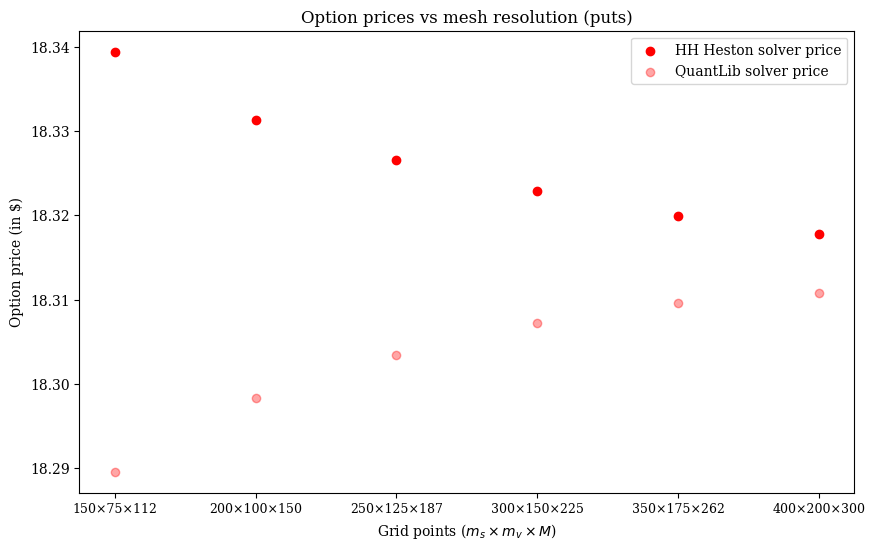

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(pricing_con.index+1, pricing_con['Model_put_estimate'], label='Haentjens-Hout estimate', c='red')
plt.scatter(pricing_con.index+1, pricing_con['QL_put_estimate'], label='QuantLib estimate', c='red', alpha=0.35)
plt.xlabel(r'Grid points ($m_s \times m_v \times M$)')
plt.xticks(pricing_con.index+1, labels=["\u00d7".join([str(pricing_con['m_s'][i]), str(pricing_con['m_v'][i]), str(pricing_con['m_t'][i])]) for i in range(len(pricing_con))], fontsize=9)
plt.title('Option prices vs mesh resolution (puts)')
plt.ylabel('Option price (in \$)');
domain1_proxy = plt.scatter([], [], color='red', label='HH Heston solver price')
domain2_proxy = plt.scatter([], [], color='red', alpha=0.35, label='QuantLib solver price')
plt.legend(handles=[domain1_proxy, domain2_proxy])
#ax11.legend(loc='lower right', bbox_to_anchor=(1, 0.15), fontsize=10);
plt.savefig("../figures/convergence_heston_pricer_put.png");

In [31]:
pricing_con['Model_call_estimate'] = pricing_con.apply(lambda row: Call.price_heston(m1=int(row['m_s']), m2=int(row['m_v']), M=int(row['m_t']))[0], axis=1)
pricing_con['QL_call_estimate'] = pricing_con.apply(lambda row: QLHestonFD.price_heston_american(Sp, K_ce, r, 0., DTE_e, v0, kappa_v, theta_v, sigma_v, rho,\
                    'call', div_dates_e, div_amounts_e, int(row['m_t']), int(row['m_s']), int(row['m_v']))['price'], axis=1)

In [32]:
pricing_con

,m_s,m_v,m_t,Model_put_estimate,QL_put_estimate,Model_call_estimate,QL_call_estimate
0,150,75,112,18.3394,18.2896,18.1958,18.1273
1,200,100,150,18.3313,18.2984,18.1803,18.1274
2,250,125,187,18.3266,18.3034,18.1691,18.1275
3,300,150,225,18.3229,18.3072,18.1608,18.1303
4,350,175,262,18.3199,18.3096,18.1543,18.1314
5,400,200,300,18.3178,18.3108,18.1492,18.1314


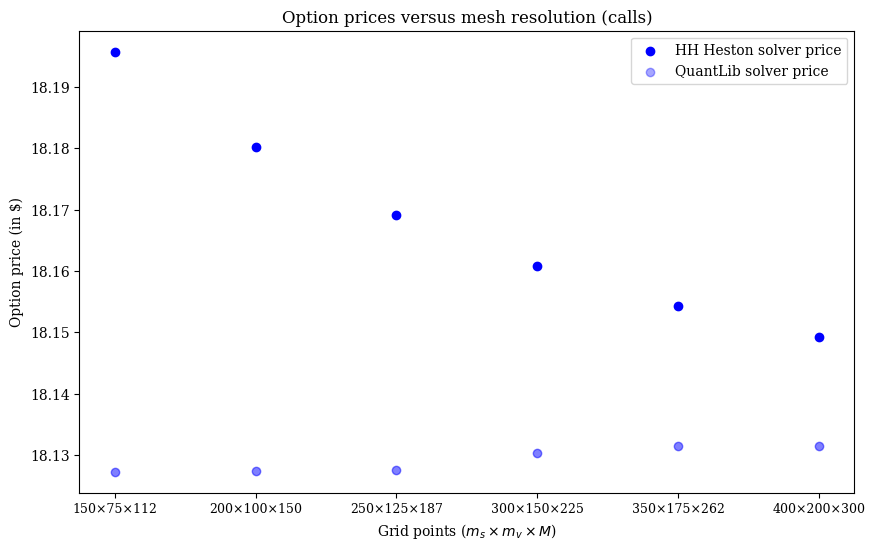

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(pricing_con.index+1, pricing_con['Model_call_estimate'], label='Model estimate', c='blue')
plt.scatter(pricing_con.index+1, pricing_con['QL_call_estimate'], label='Model estimate', c='blue', alpha=0.5)
plt.xlabel(r'Grid points ($m_s \times m_v \times M$)')
plt.xticks(pricing_con.index+1, labels=["\u00d7".join([str(pricing_con['m_s'][i]), str(pricing_con['m_v'][i]), str(pricing_con['m_t'][i])]) for i in range(len(pricing_con))], fontsize=9)
plt.title('Option prices versus mesh resolution (calls)')
plt.ylabel('Option price (in \$)');
domain1_proxy = plt.scatter([], [], color='blue', label='HH Heston solver price')
domain2_proxy = plt.scatter([], [], color='blue', alpha=0.35, label='QuantLib solver price')
plt.legend(handles=[domain1_proxy, domain2_proxy])
plt.savefig("../figures/convergence_heston_pricer_call.png");

In addition to reproducing benchmark option prices reported in the literature, the proposed finite-difference solver generates American option prices that closely agree with those produced by the QuantLib pricing engine. The pricing discrepancies are typically on the order of a few cents and decrease consistently as the spatial, temporal, and variance grid resolutions are refined. The remaining differences can be attributed to implementation-specific factors, including grid construction, interpolation schemes, operator splitting, and the treatment of discrete dividends, rather than to any fundamental differences in the underlying Heston model.  Furthermore, when used alongside the QuantLib pricing engine, the proposed solver provides a tighter bound on the true option value.

In the HH solver, at each time step, an LU factorization of the matrices associated with the operators $I - \theta \Delta t A_i$ ($i=1,2$), is recomputed, even though these matrices remain unchanged between dividend dates and their factorization could, in principle, be reused. This design choice stems from the fact that SciPy's native tridiagonal solvers operate directly on the subdiagonal, diagonal, and superdiagonal vectors. Consequently, the computational performance of the HH solver could be improved significantly by restructuring the linear solver to reuse precomputed (LU) factorizations whenever the operator matrices remain unchanged. Such an enhancement would preserve the existing numerical framework while reducing the overall runtime.

Several factors may contribute to the mispricing with the actual market values:
* The calibrated Heston parameters may not fully capture the dynamics implied by the market option surface.
* The spot prices inferred from E-mini S&P 500 futures using the approximation
  $$
  S^{\text{SPY}}_0(T) \approx \frac{S^{\text{SP500}}_0(T)}{10}
  $$
  are only estimates and may introduce errors.
* The risk-free rate derived from SOFR data is itself an approximation and may differ from the market-implied financing rate relevant for option pricing.
* The calibration is performed using European SPX options, whereas the pricing exercise is conducted on American SPY options with discrete dividends. Consequently, model parameters that accurately reproduce the SPX volatility surface may not perfectly capture the pricing dynamics of SPY options.

---
### Optimal Exercise Boundary under Heston Stochastic Volatility Framework

The defining feature of an American option is the holder's right to exercise the contract at any time prior to maturity. This gives rise to a free-boundary problem, where the optimal exercise boundary separates the continuation region from the exercise region.

Under the Heston stochastic volatility framework, the option value depends not only on the underlying asset price, $S$ and time, $t$, but also on the instantaneous variance, $v$. Consequently, the optimal exercise threshold becomes a two-dimensional surface, denoted by $S^*(v,t)$, rather than the one-dimensional boundary encountered in the Black–Scholes model.

For American put options, early exercise may be optimal when the asset price is sufficiently low. The exercise region is therefore characterised by $S \leq S^*(v,t)$, while continuation is optimal above the boundary. The dependence on variance reflects the trade-off between immediate exercise and the time value of the option. Higher volatility generally increases the value of waiting, causing the critical stock price to decrease and shrinking the exercise region.

In contrast, for American call options on non-dividend-paying assets, early exercise is usually never optimal. The continuation value is less than the intrinsic value prior to maturity at unusually high asset prices. As a result, the premium for early exercise of American calls is very low.

The introduction of discrete cash dividends fundamentally alters this picture. Dividend payments induce downward jumps in the stock price at ex-dividend dates, creating an incentive to exercise call options immediately before the dividend in order to acquire the underlying asset and receive the dividend payment. An economically-feasible exercise boundary therefore emerges for American calls in the vicinity of ex-dividend dates. In backward time, this boundary appears abruptly as the dividend date is crossed and disappears immediately afterwards. At the ex-dividend date, the critical asset price is obtained from the equation, $V(S^*, v, t_{i}^{-}) = S^* - K + D_i$, where $t_i$ and $D_i$ are the dividend date and dividend amount respectively.

Discrete dividends also modify the exercise behaviour of American puts. The prospect of future dividend-induced declines in the stock price enhances the value of remaining invested in the option, altering both the shape and location of the put exercise surface. The resulting free boundary exhibits discontinuities across dividend dates and must be evolved together with the dividend jump condition imposed on the option value. The extraction and visualisation of these exercise surfaces provide valuable insight into the interplay between stochastic volatility, early exercise incentives, and the impact of discrete dividends on American option valuation.

### Greeks for American options

For American options, the Greeks are particularly important because the option value depends not only on the underlying market variables but also on the possibility of optimal early exercise. Consequently, the sensitivities can exhibit features that are absent in their European counterparts, in the vicinity of the early exercise boundary. Accurate estimation of the Greeks is therefore essential for hedging and risk management, especially for dividend-paying equity options where early exercise may be optimal. Moreover, the Greeks provide a stringent validation of a numerical pricing engine, as they are generally more sensitive to discretisation, interpolation, and mesh refinement than option prices themselves.

In [34]:
Put = HestonFD.HestonFD_ADI_HV(Sp, r, K_pe, DTE_e/365., 'put', heston_calibrated_params,\
                                           dividend_dates=np.array(div_dates_e)/365., dividend_amounts=np.array(div_amounts_e))
Call = HestonFD.HestonFD_ADI_HV(Sp, r, K_ce, DTE_e/365., 'call', heston_calibrated_params,\
                                            dividend_dates=np.array(div_dates_e)/365., dividend_amounts=np.array(div_amounts_e))
Put_price, Put_delta, Put_vega = Put.price_heston(m1=500, m2=250, M=375, display_exercise=True)
Call_price, Call_delta, Call_vega = Call.price_heston(m1=500, m2=250, M=375, display_exercise=True)

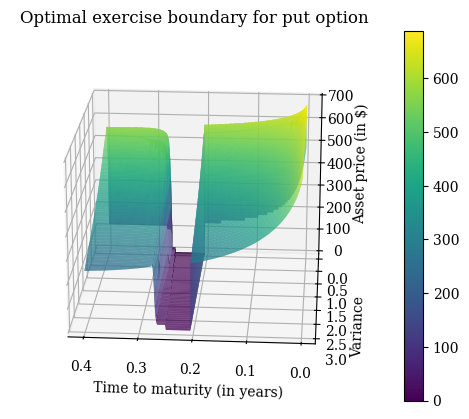

In [35]:
Put.plot_exercise_boundary(elev = 20, azim = 94)

As calendar time advances (equivalently, as the time-to-maturity decreases), the optimal exercise boundary remains smooth until a few days before the ex-dividend date. During this period, the critical asset price decreases sharply and approaches zero. On the ex-dividend date itself, the exercise boundary collapses to zero, indicating that immediate exercise is suboptimal across the asset-price domain. Following the dividend payment, the boundary re-emerges and rises as maturity approaches, reflecting the increasing attractiveness of early exercise for deep in-the-money put options.

Across the variance dimension, the critical asset price exhibits an overall decreasing trend. Higher variance increases the likelihood of large downward movements in the underlying asset price, thereby enhancing the probability that the put option will move further into the money. As a result, the holder is willing to delay exercise until a lower asset-price threshold is reached, leading to a downward shift of the exercise boundary with increasing variance.

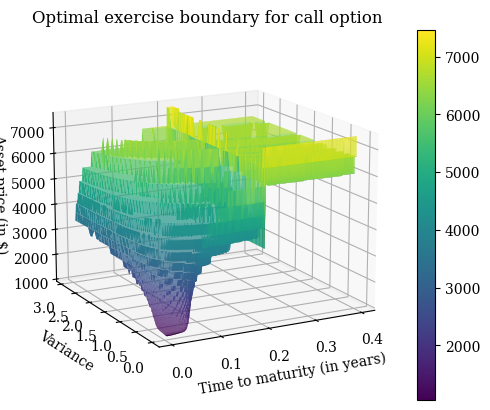

In [36]:
Call.plot_exercise_boundary(elev=15,azim=242)

The exercise boundary appears jagged due to the relatively coarse discretisation of the asset-price grid at higher stock prices. For American call options, early exercise is generally suboptimal, meaning that the critical exercise boundary, when it exists, is typically located at relatively high asset prices, often close to the upper computational boundary, $S=S_{\max}$. Consequently, numerical artefacts arising from the finite grid resolution and domain truncation become more pronounced in this region. Rather than attempting to determine the exact critical asset price, the exercise boundary is approximated by the midpoint of the two adjacent asset-price grid nodes between which the exercise decision changes.

As calendar time advances, the critical asset price remains nearly constant before experiencing a sharp decline immediately prior to the ex-dividend date. This behavior is expected, as early exercise of an American call option becomes increasingly attractive just before a dividend payment in order to capture the dividend. On the ex-dividend date, the exercise boundary collapses and subsequently re-emerges. Following the dividend payment, the critical asset price gradually decreases as the option approaches maturity.

As with American put options, an increase in variance raises the probability of large movements in the underlying asset price. For call options, higher variance increases the potential for substantial upward price movements, thereby enhancing the continuation value of the option. Consequently, the holder is willing to delay exercise until a higher asset-price threshold is reached, resulting in an upward shift of the exercise boundary as variance increases.

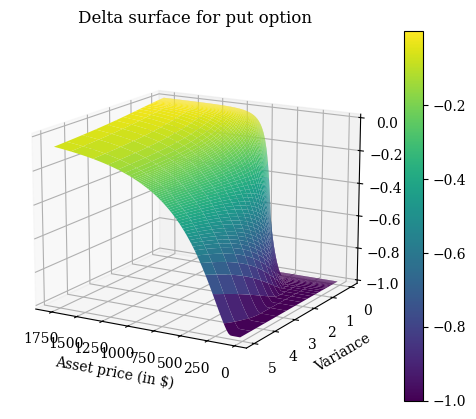

In [37]:
Put.plot_delta_surface(elev = 15, azim = 120)

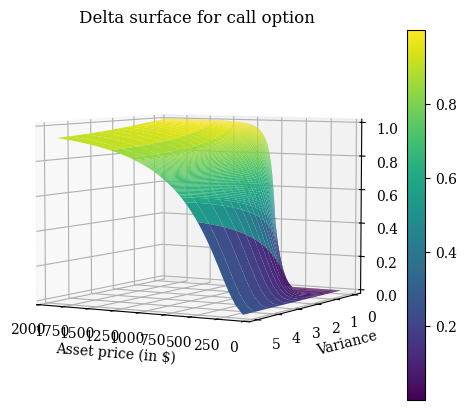

In [38]:
Call.plot_delta_surface(elev = 5, azim = 120)

For the put option, $\Delta$ increases sharply from approximately $−1$ to $0$ as the asset price rises from $0$ to $S_\text{max}$ near the strike price. As the variance increases, this transition becomes progressively more gradual, reflecting the greater uncertainty in the future evolution of the underlying asset. Higher volatility broadens the range of asset prices over which the option transitions between deep in-the-money and deep out-of-the-money states, resulting in a smoother $\Delta$ profile. A similar behaviour is observed for the call option, whose $\Delta$ increases from $0$ to $1$. In both cases, the sensitivity is greatest in the vicinity of the strike price, where small changes in the underlying asset price have the largest impact on the option value. This behaviour arises from the transition between the continuation and exercise regions and serves as a characteristic signature of the free-boundary problem.

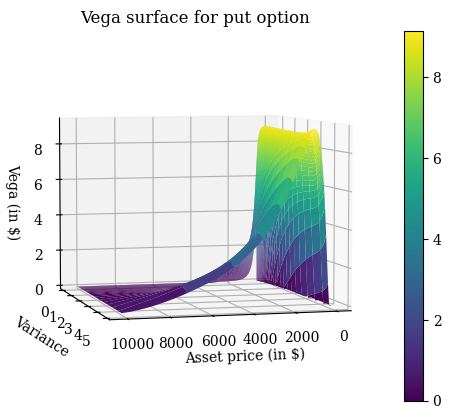

In [39]:
Put.plot_vega_surface(elev = 5, azim = 75)

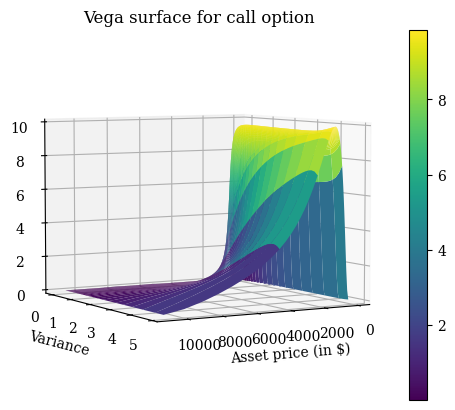

In [40]:
Call.plot_vega_surface(elev = 5, azim = 60)

It can be seen that Vega is most pronounced in the vicinity of the strike price for both put and call options, where the option value is most sensitive to changes in volatility. As the variance increases, Vega generally becomes larger, reflecting the greater influence of volatility fluctuations on the option price. For at-the-money (ATM) options, calls and puts exhibit nearly identical Vega values, since an increase in volatility raises the probability of large price movements in either direction. Consequently, both contracts benefit from the increased likelihood of ending up significantly in the money.

Vega decreases as the option moves deeper into either the in-the-money or out-of-the-money regions, where the payoff becomes increasingly determined by the current asset price rather than future uncertainty. In the Heston framework, the Vega surface also depends on the instantaneous variance state, causing volatility sensitivity to vary across both the asset-price and variance dimensions. The resulting surface provides a useful measure of the option's exposure to stochastic volatility risk and highlights the regions where volatility dynamics have the greatest impact on valuation.